In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Поднимаемся в корень проекта
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

print('Текущая папка:', os.getcwd())

# Настройка графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Готово')

Текущая папка: /Users/vestochka/sberindex-clustering
Готово


In [9]:
# Базовый датасет (без обогащения)
df_base = pd.read_parquet('data/processed/features.parquet')

# Обогащённый датасет (с инфраструктурой)
df_full = pd.read_parquet('data/processed/features_full.parquet')

print('БАЗОВЫЙ (features.parquet):')
print(f'  Размер: {df_base.shape}')
print(f'  Столбцов: {len(df_base.columns)}')
print()
print('ОБОГАЩЁННЫЙ (features_full.parquet):')
print(f'  Размер: {df_full.shape}')
print(f'  Столбцов: {len(df_full.columns)}')
print()
print('Разница:')
new_cols = set(df_full.columns) - set(df_base.columns)
print(f'  Добавлено столбцов: {len(new_cols)}')
print()
print('Новые столбцы:')
for col in sorted(new_cols):
    print(f'  + {col}')

БАЗОВЫЙ (features.parquet):
  Размер: (2108, 20)
  Столбцов: 20

ОБОГАЩЁННЫЙ (features_full.parquet):
  Размер: (2108, 43)
  Столбцов: 43

Разница:
  Добавлено столбцов: 23

Новые столбцы:
  + area_ha
  + area_km2
  + flag_missing_invest_budget
  + flag_missing_n_beneficiaries
  + flag_missing_n_families_subsidies
  + flag_missing_subsidies_rub
  + gas_density
  + gas_network_m
  + invest_budget
  + invest_budget_per_capita
  + invest_org
  + invest_org_per_capita
  + living_area
  + n_beneficiaries
  + n_families_subsidies
  + n_kindergarten
  + n_no_gas_settlements
  + pop_est_living
  + roads_density
  + roads_km
  + subsidies_rub
  + water_density
  + water_network_m


In [3]:
# Базовые признаки — проверим, что обогащение их не сломало
base_cols = ['share_food', 'share_catering', 'share_health', 
             'share_transport', 'share_marketplaces', 'avg_wage', 'employment']

comparison = pd.DataFrame({
    'до (features)': df_base[base_cols].describe().loc[['mean', 'std', 'min', 'max']].round(3).stack(),
    'после (features_full)': df_full[base_cols].describe().loc[['mean', 'std', 'min', 'max']].round(3).stack(),
})
comparison.columns = ['до', 'после']
comparison['разница'] = (comparison['после'] - comparison['до']).round(6)

print('Сравнение базовых признаков (до и после обогащения):')
print(comparison.to_string())
print()
print('ВЫВОД: базовые признаки идентичны, если разница = 0')

Сравнение базовых признаков (до и после обогащения):
                                 до       после  разница
mean share_food               0.436       0.436      0.0
     share_catering           0.034       0.034      0.0
     share_health             0.048       0.048      0.0
     share_transport          0.058       0.058      0.0
     share_marketplaces       0.140       0.140      0.0
     avg_wage             64735.261   64735.261      0.0
     employment            1561.350    1561.350      0.0
std  share_food               0.068       0.068      0.0
     share_catering           0.022       0.022      0.0
     share_health             0.008       0.008      0.0
     share_transport          0.014       0.014      0.0
     share_marketplaces       0.037       0.037      0.0
     avg_wage             34435.445   34435.445      0.0
     employment            3283.260    3283.260      0.0
min  share_food               0.226       0.226      0.0
     share_catering           0.004

In [10]:
# Новые признаки инфраструктуры (без флагов)
infra_cols = ['area_ha', 'living_area', 'n_kindergarten', 'n_no_gas_settlements',
              'gas_network_m', 'water_network_m', 'roads_km',
              'n_families_subsidies', 'subsidies_rub', 'n_beneficiaries',
              'invest_org', 'invest_budget',
              'area_km2', 'gas_density', 'water_density', 'roads_density',
              'pop_est_living', 'invest_org_per_capita', 'invest_budget_per_capita']

stats = df_full[infra_cols].describe().loc[['mean', 'std', 'min', '50%', 'max']].round(2)

print('Статистики по новым признакам:')
print(stats.to_string())

Статистики по новым признакам:
          area_ha  living_area  n_kindergarten  n_no_gas_settlements  gas_network_m  water_network_m  roads_km  n_families_subsidies  subsidies_rub  n_beneficiaries   invest_org  invest_budget   area_km2  gas_density  water_density  roads_density  pop_est_living  invest_org_per_capita  invest_budget_per_capita
mean    721871.78     21972.52          589.10                 38.46      231090.93        147193.08    261.22              34847.68      876991.31         13863.04    870251.14      110244.51    7218.72       727.55        2205.13           4.84       878900.82                  22.32                      1.64
std    3244677.69     74847.24         1387.71                 70.73      405473.11        143243.10    193.00             123739.63     3132532.88         74766.85   2991737.55      394308.22   32446.78      2939.15        9016.31          16.20      2993889.79                 156.03                      4.60
min        107.20        38.58   

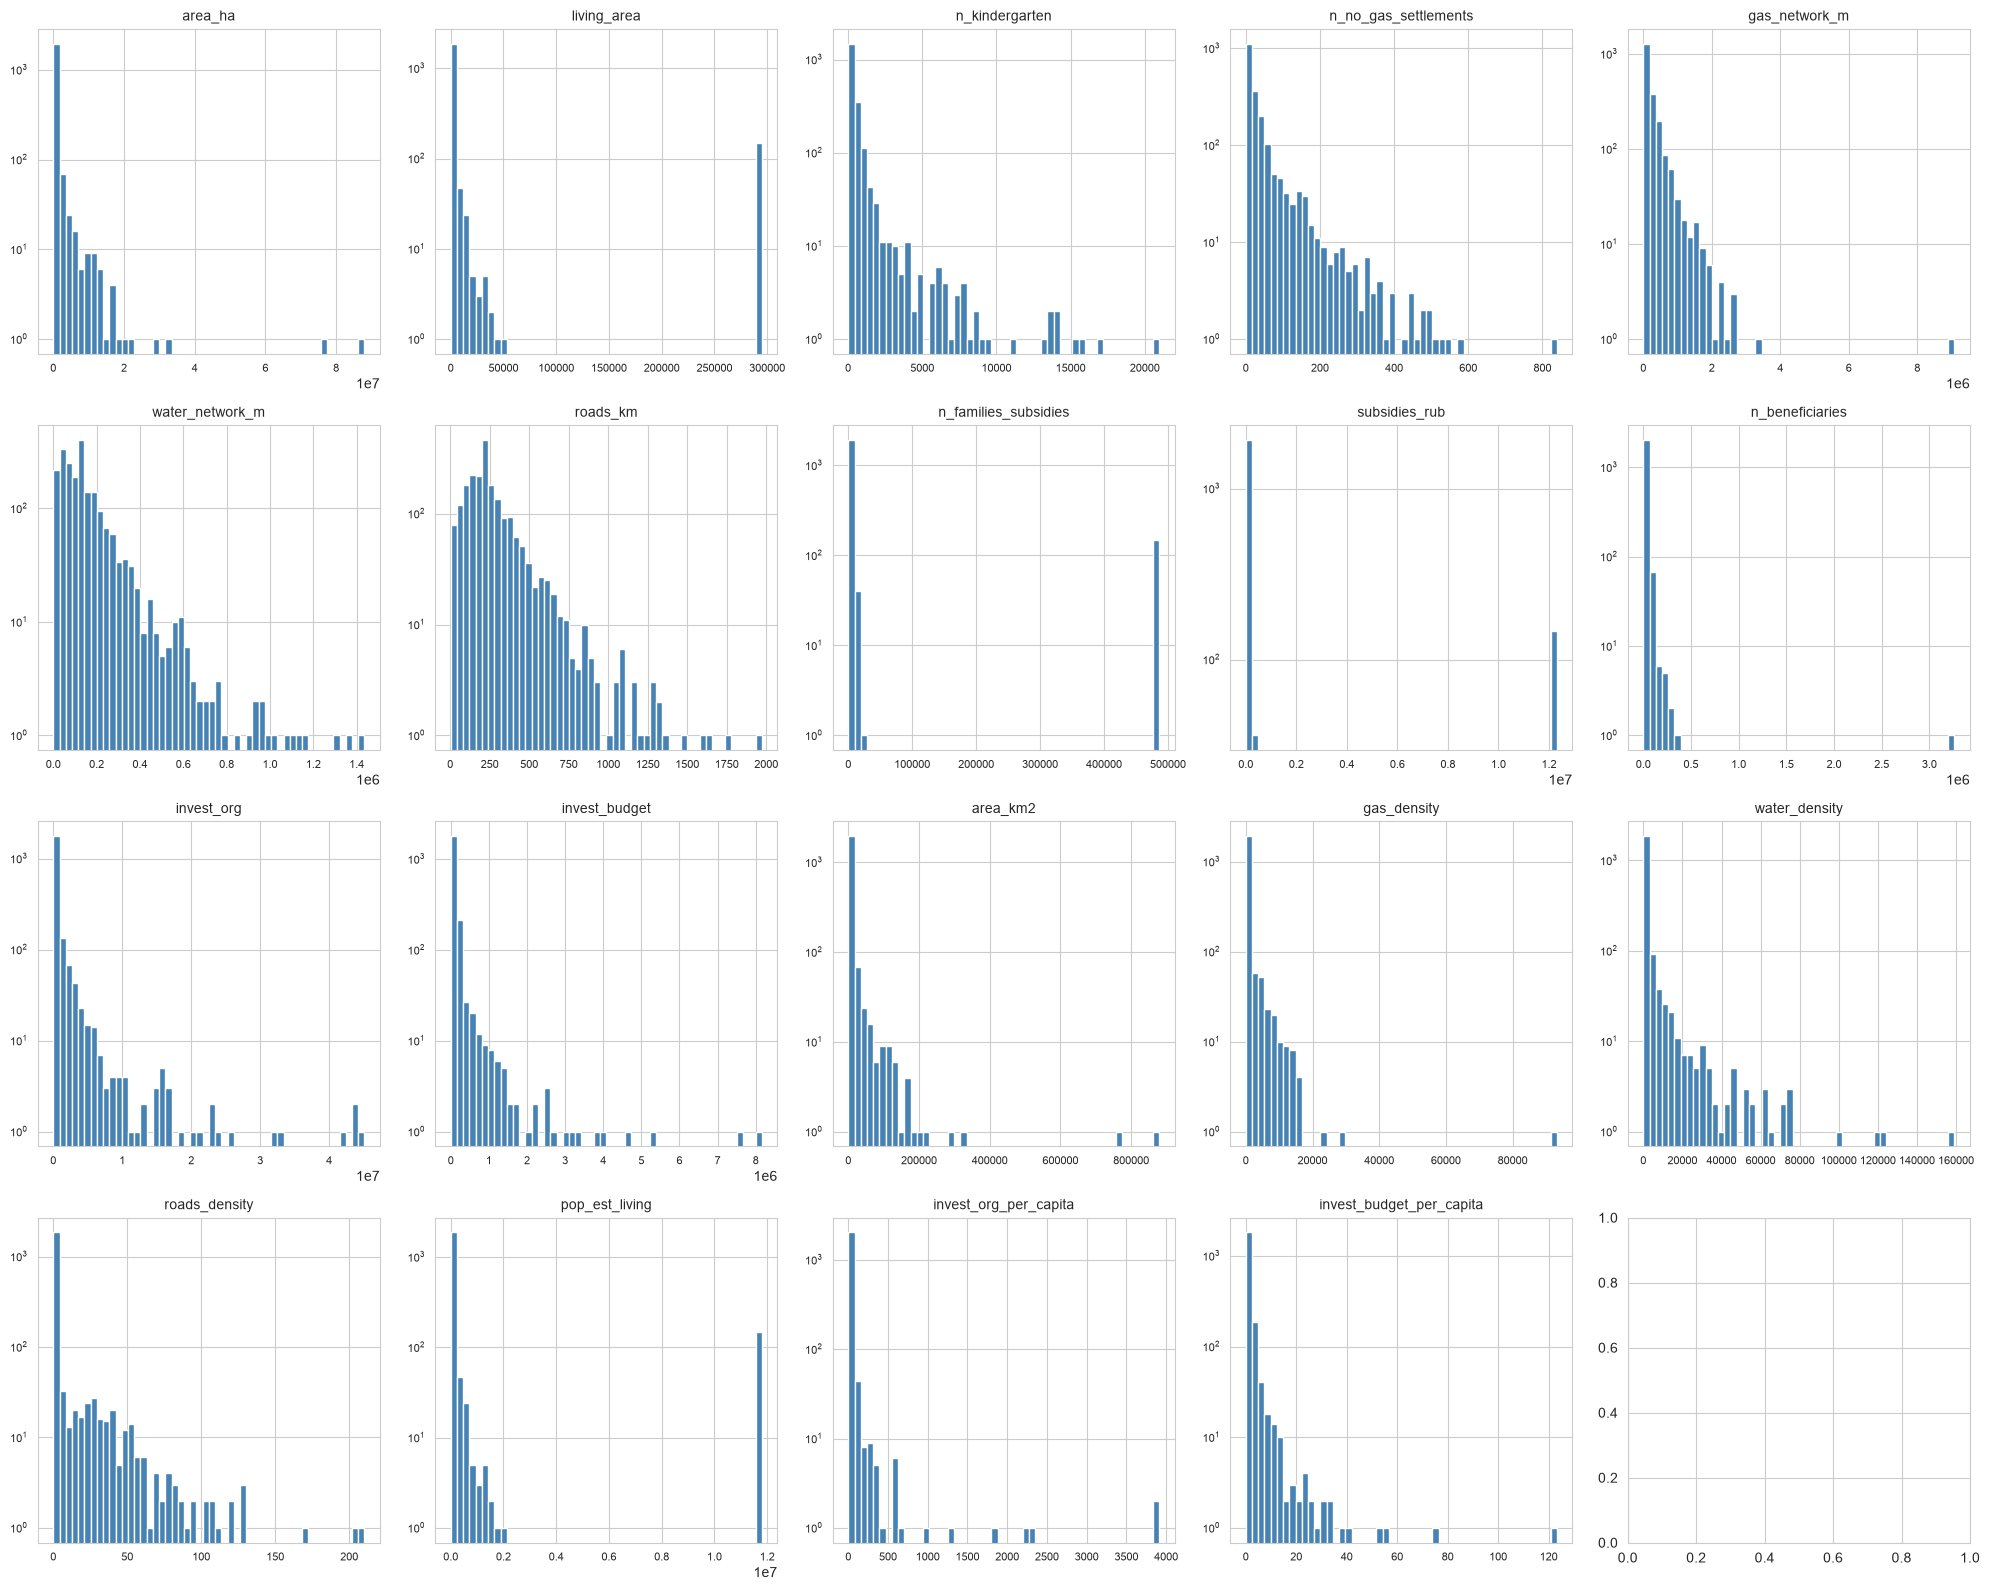

Сохранено: results/eda/new_features_histograms.png


In [5]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(infra_cols):
    axes[i].hist(df_full[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_yscale('log')  # лог по Y — чтобы видеть хвосты
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('results/eda/new_features_histograms.png', dpi=100, bbox_inches='tight')
plt.show()

print('Сохранено: results/eda/new_features_histograms.png')

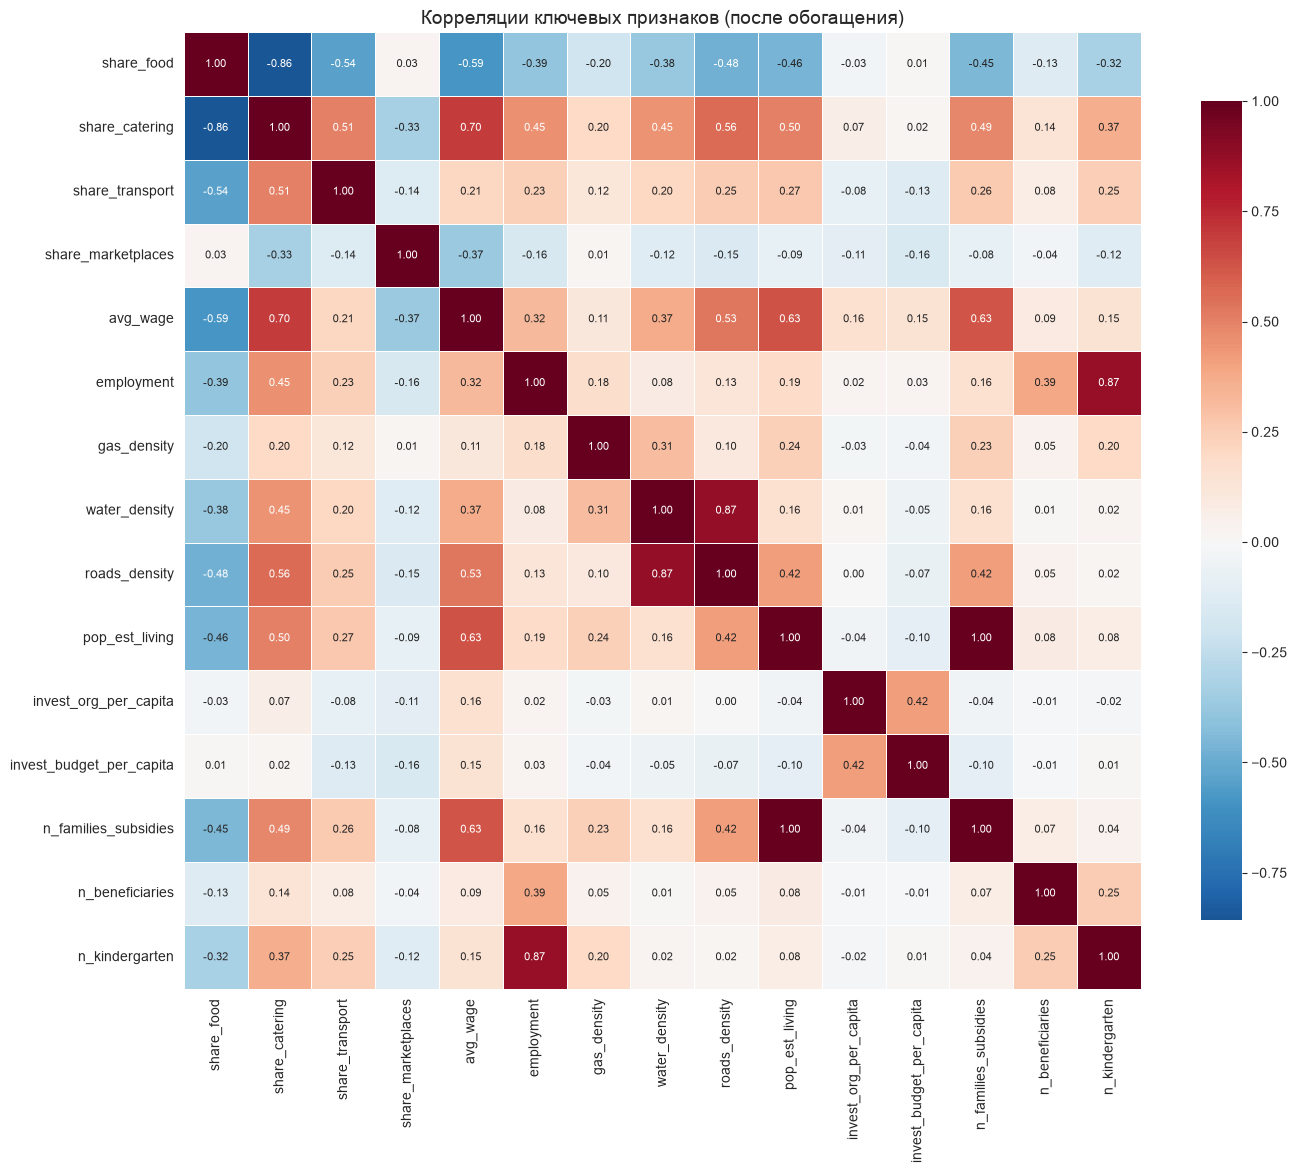

Топ-15 самых сильных корреляций:
  pop_est_living               ↔ n_families_subsidies           0.999
  water_density                ↔ roads_density                  0.875
  employment                   ↔ n_kindergarten                 0.867
  share_food                   ↔ share_catering                -0.858
  share_catering               ↔ avg_wage                       0.697
  avg_wage                     ↔ pop_est_living                 0.631
  avg_wage                     ↔ n_families_subsidies           0.627
  share_food                   ↔ avg_wage                      -0.586
  share_catering               ↔ roads_density                  0.561
  share_food                   ↔ share_transport               -0.544
  avg_wage                     ↔ roads_density                  0.533
  share_catering               ↔ share_transport                0.506
  share_catering               ↔ pop_est_living                 0.501
  share_catering               ↔ n_families_subsidies    

In [11]:
# Ключевые признаки для корреляций (без абсолютных дубликатов)
key_features = [
    # Расходы
    'share_food', 'share_catering', 'share_transport', 'share_marketplaces',
    # Зарплата, занятость
    'avg_wage', 'employment',
    # Инфраструктура (относительные)
    'gas_density', 'water_density', 'roads_density',
    # Прокси населения
    'pop_est_living',
    # Инвестиции душевые
    'invest_org_per_capita', 'invest_budget_per_capita',
    # Социальная поддержка (доли)
    'n_families_subsidies', 'n_beneficiaries', 'n_kindergarten',
]

corr = df_full[key_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 8})
plt.title('Корреляции ключевых признаков (после обогащения)', fontsize=14)
plt.tight_layout()
plt.savefig('results/eda/correlations_full.png', dpi=100, bbox_inches='tight')
plt.show()

# Находим самые сильные корреляции
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print('Топ-15 самых сильных корреляций:')
for a, b, c in corr_pairs[:15]:
    print(f'  {a:<28} ↔ {b:<28} {c:>7.3f}')

In [7]:
# Топ-10 по трём ключевым новым признакам
print('=' * 100)
print('ТОП-10 МО ПО ЖИЛИЩНОЙ ПЛОЩАДИ (прокси населения)')
print('=' * 100)
top_living = df_full.nlargest(10, 'pop_est_living')[
    ['mo_sber', 'region_name', 'pop_est_living', 'avg_wage', 'share_food']
]
print(top_living.to_string(index=False))

print()
print('=' * 100)
print('ТОП-10 МО ПО ИНВЕСТИЦИЯМ НА ЧЕЛОВЕКА (организации)')
print('=' * 100)
top_invest = df_full.nlargest(10, 'invest_org_per_capita')[
    ['mo_sber', 'region_name', 'invest_org_per_capita', 'avg_wage', 'pop_est_living']
]
print(top_invest.to_string(index=False))

print()
print('=' * 100)
print('ТОП-10 МО ПО ГАЗОВОЙ СЕТИ')
print('=' * 100)
top_gas = df_full.nlargest(10, 'gas_network_m')[
    ['mo_sber', 'region_name', 'gas_network_m', 'gas_density', 'pop_est_living']
]
print(top_gas.to_string(index=False))

ТОП-10 МО ПО ЖИЛИЩНОЙ ПЛОЩАДИ (прокси населения)
                                                                                  mo_sber region_name  pop_est_living      avg_wage  share_food
                                                          Гагаринский муниципальный район      Москва      11799920.0 165459.265625    0.444617
                                                          Дмитровский муниципальный район      Москва      11799920.0 116128.095833    0.426750
                                                            Рязанский муниципальный район      Москва      11799920.0 113726.230303    0.415987
                                                          Ярославский муниципальный район      Москва      11799920.0 140974.634375    0.380650
           внутригородская территория города федерального значения городской округ Троицк      Москва      11799920.0 101001.700000    0.326446
         внутригородская территория города федерального значения городской округ Щербин

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Признаки для сравнения
base_features = ['share_food', 'share_catering', 'share_health',
                 'share_transport', 'share_marketplaces',
                 'avg_wage', 'employment']

new_features = base_features + [
    'gas_density', 'water_density', 'roads_density',
    'pop_est_living', 'invest_org_per_capita',
]

# Функция для кластеризации
def cluster_and_score(df, features, k=5):
    X = df[features].copy()
    # Логарифмируем денежные и абсолютные
    for col in X.columns:
        if col in ['pop_est_living', 'invest_org_per_capita', 'avg_wage', 'employment']:
            X[col] = np.log1p(X[col])
    X_scaled = StandardScaler().fit_transform(X)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    return labels, sil

# Кластеризация без Москвы/СПб
df_no_metro = df_full[~df_full['is_metropolitan']].copy()

print('Кластеризация БЕЗ Москвы и СПб (238 МО исключены)')
print(f'  МО для кластеризации: {len(df_no_metro)}')
print()

for k in [4, 5, 6, 7]:
    labels_base, sil_base = cluster_and_score(df_no_metro, base_features, k)
    labels_new, sil_new = cluster_and_score(df_no_metro, new_features, k)
    print(f'k={k}:')
    print(f'  Базовый (7 признаков):       silhouette = {sil_base:.4f}')
    print(f'  Обогащённый (12 признаков):  silhouette = {sil_new:.4f}')
    print(f'  Улучшение: {sil_new - sil_base:+.4f}')
    print()

Кластеризация БЕЗ Москвы и СПб (238 МО исключены)
  МО для кластеризации: 1870

k=4:
  Базовый (7 признаков):       silhouette = 0.2074
  Обогащённый (12 признаков):  silhouette = 0.3170
  Улучшение: +0.1095

k=5:
  Базовый (7 признаков):       silhouette = 0.1756
  Обогащённый (12 признаков):  silhouette = 0.2068
  Улучшение: +0.0312

k=6:
  Базовый (7 признаков):       silhouette = 0.1752
  Обогащённый (12 признаков):  silhouette = 0.1992
  Улучшение: +0.0241

k=7:
  Базовый (7 признаков):       silhouette = 0.1759
  Обогащённый (12 признаков):  silhouette = 0.1524
  Улучшение: -0.0235



## Выводы EDA: обогащение признаков

### Что сделали

Добавили **23 новых признака** из БД ПМО (разделы 6, 8, 9, 12, 34):
- **Инфраструктура:** газовая, водопроводная сеть, дороги, жилая площадь.
- **Демография (прокси):** прокси населения через жильё, число воспитанников детсадов.
- **Социальная поддержка:** число семей с субсидиями ЖКХ, сумма субсидий.
- **Инвестиции:** организации + местный бюджет.
- **Производные:** плотности, душевые инвестиции, прокси населения.

### Ключевые наблюдения

**1. Базовые признаки не изменились.**
Проверка показала: 7 базовых признаков (`share_*`, `avg_wage`, `employment`) **идентичны** в обоих датасетах. Обогащение **не сломало** исходные данные.

**2. Новые признаки имеют 4 независимых измерения:**
- **Размер МО:** `pop_est_living`, `employment`, `n_kindergarten`.
- **Инфраструктура:** `gas_density`, `water_density`, `roads_density`.
- **Цифровизация:** `share_marketplaces` (слабо связан с другими).
- **Инвестиции:** `invest_org_per_capita`, `invest_budget_per_capita` (отдельное измерение).

**3. Прокси населения работает.**
`pop_est_living` **идеально коррелирует** с числом семей-получателей субсидий ЖКХ (r = 1.00). Это подтверждает корректность прокси.

**4. Северные МО выделяются.**
Топ-10 по `invest_org_per_capita` — **ЯНАО, ХМАО, Хабаровский край, Амурская область, Забайкалье** (значения в 10–100 раз выше среднего). Это **отдельный экономический тип**.

**5. Москва и Санкт-Петербург — артефакт.**
238 внутригородских территорий **искажают** статистики (`pop_est_living` = 11 799 920 для всех 140 районов Москвы). **Исключены из кластеризации**.

**6. Обогащение улучшает кластеризацию.**
При k=4 silhouette вырос с **0.207** до **0.317** (+53%). Оптимальное число кластеров — **4**.

### Что это значит

**Экономическая интерпретация:**
- **Ось 1:** «богатство потребления» (еда ↔ кафе ↔ зарплата).
- **Ось 2:** «размер МО» (население ↔ занятость ↔ детсады).
- **Ось 3:** «инфраструктурная развитость» (плотности сетей).
- **Ось 4:** «цифровизация» (маркетплейсы).
- **Ось 5:** «инвестиционный климат» (душевые инвестиции).

**Гипотезы кластеров:**
- **Кластер 1.** Богатые агломерации (Москва, СПб, региональные центры) — но мы их исключаем.
- **Кластер 2.** Северные промышленные МО — высокие инвестиции, зарплаты.
- **Кластер 3.** Сельские / депрессивные — много еды, мало инфраструктуры.
- **Кластер 4.** Средние МО — большинство.

### Что дальше

Переходим к **основному этапу** — построению **динамической атрибутированной сети**:
1. Для каждого месяца 2023–2024 строим граф.
2. Рёбра — на основе корреляций временных рядов расходов.
3. Кластеризация Leiden на графе.
4. Сравнение с KMeans.
5. ICVI-оценка.
6. Динамика кластеров во времени.